# Breakdowns — chemistry & cell line

Per-slice ranking skill with sample counts and inhibition ranges, so a strong number can't
hide in a narrow-variance slice. Reads the same `results/` (see `_viz.py`).

In [1]:
import _viz as v
v.setup_style()
import numpy as np, pandas as pd, matplotlib.pyplot as plt
R = v.load_results()
summary, preds = R['summary'], v.add_cohort_mean(R['preds'])
breakdown = R['breakdown']
print('test oligos:', len(preds), '| custom_id cohorts:', preds.custom_id.nunique(), '| scorers:', summary.scorer.nunique())

test oligos: 20846 | custom_id cohorts: 269 | scorers: 11


## Per chemistry — cEt vs 2'MOE gapmers
Bar = median per-cohort Spearman; dots = the per-cohort distribution; black tick = mean (μ).

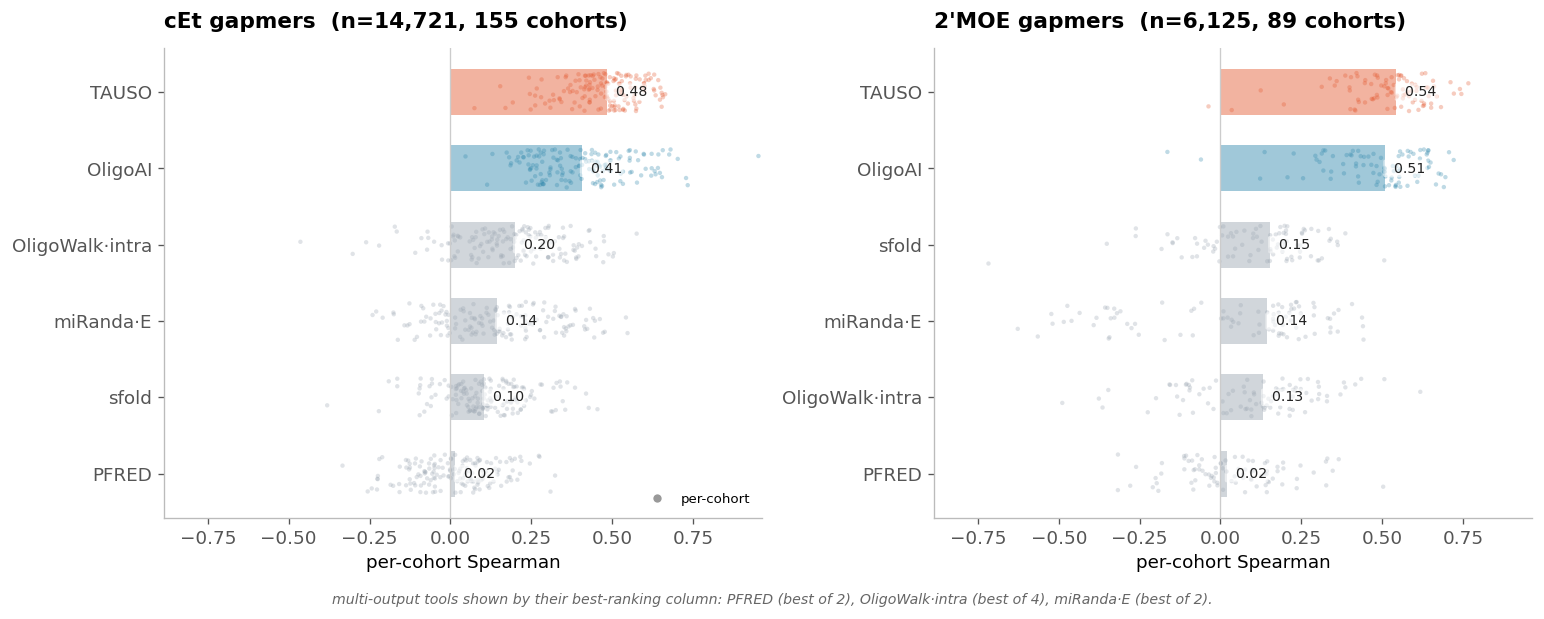

In [2]:
from matplotlib.lines import Line2D
chem = breakdown[breakdown.breakdown=='chemistry']
reps, note = v.best_representatives(summary)
show = v.SINGLES + reps
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for a, cv in zip(ax, ["cEt", "2'MOE"]):
    sub = preds[preds.chemistry==cv]
    dist = {s: v.per_cohort_spearman(sub, s) for s in show}
    o = sorted([s for s in show if len(dist[s])], key=lambda s: (s!='TAUSO', -np.median(dist[s])))
    v.hbar_dist(a, o, [np.median(dist[s]) for s in o], [dist[s] for s in o],
                title=f'{cv} gapmers  (n={len(sub):,}, {dist["TAUSO"].size} cohorts)', xlabel='per-cohort Spearman')
ax[0].legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor='#999',markersize=6,label='per-cohort')],
             frameon=False, fontsize=8, loc='lower right')
fig.text(0.5, -0.02, v.rep_caption(note), ha='center', fontsize=8.5, color='#666', style='italic')
plt.tight_layout(); plt.show()

In [3]:
# descriptive + TAUSO/OligoAI per chemistry
desc = chem.drop_duplicates('slice').set_index('slice')[['n_samples','n_genes','n_cohorts_total','inhib_mean','base_hit70']]
for s in ['TAUSO','oligo_ai_score']:
    desc[v.disp(s)] = chem[chem.scorer==s].set_index('slice')['spearman_median']
desc.round({'inhib_mean':1,'base_hit70':3,'TAUSO':3,'OligoAI':3})

,n_samples,n_genes,n_cohorts_total,inhib_mean,base_hit70,TAUSO,OligoAI
slice,,,,,,,
2'MOE,6125,20,127,53.4,0.342,0.541,0.508
cEt,14721,6,177,42.9,0.227,0.484,0.405


## Per cell line
Sorted by sample count; **HUVEC** is tiny in test and excluded by the cohort threshold — fine to miss.

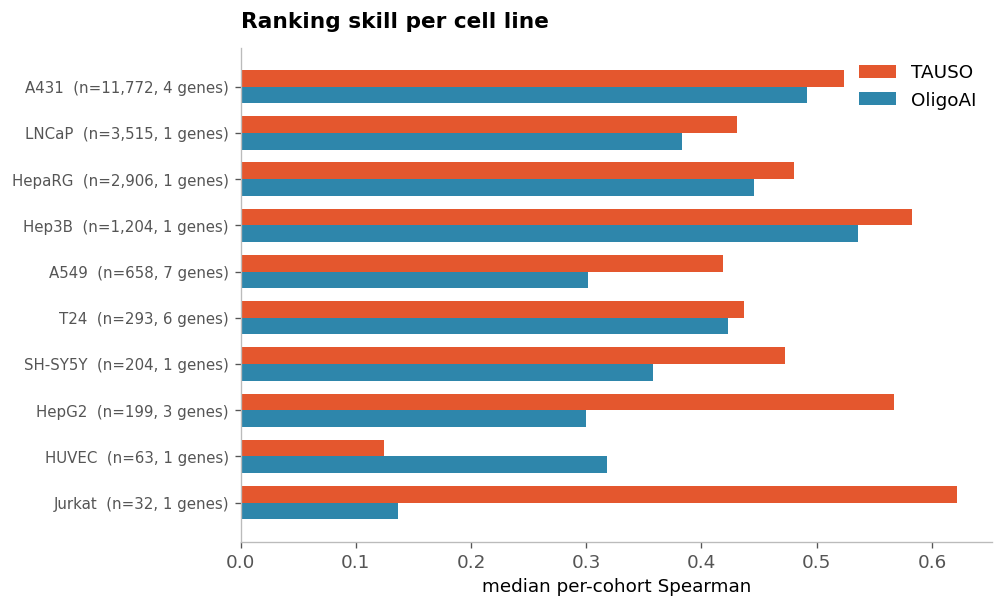

In [4]:
cell = breakdown[breakdown.breakdown=='Cell_line']
ta = cell[cell.scorer=='TAUSO'].set_index('slice').sort_values('n_samples', ascending=False)
oa = cell[cell.scorer=='oligo_ai_score'].set_index('slice')['spearman_median']
fig, ax = plt.subplots(figsize=(8.5, 5.2))
y = np.arange(len(ta))[::-1]
ax.barh(y+.18, ta['spearman_median'].values, .36, color=v.ACCENT, label='TAUSO')
ax.barh(y-.18, oa.reindex(ta.index).values, .36, color=v.BLUE, label='OligoAI')
ax.set_yticks(y); ax.set_yticklabels([f'{c}  (n={int(n):,}, {int(g)} genes)' for c, n, g in zip(ta.index, ta.n_samples, ta.n_genes)], fontsize=9)
ax.set_xlabel('median per-cohort Spearman'); ax.set_title('Ranking skill per cell line'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### Per-cell-line distribution (TAUSO)
Median bar + per-cohort distribution + mean, sorted by cohort count; OligoAI median marked for reference. Small-n cell lines (HUVEC = 1 cohort) are visually obvious.

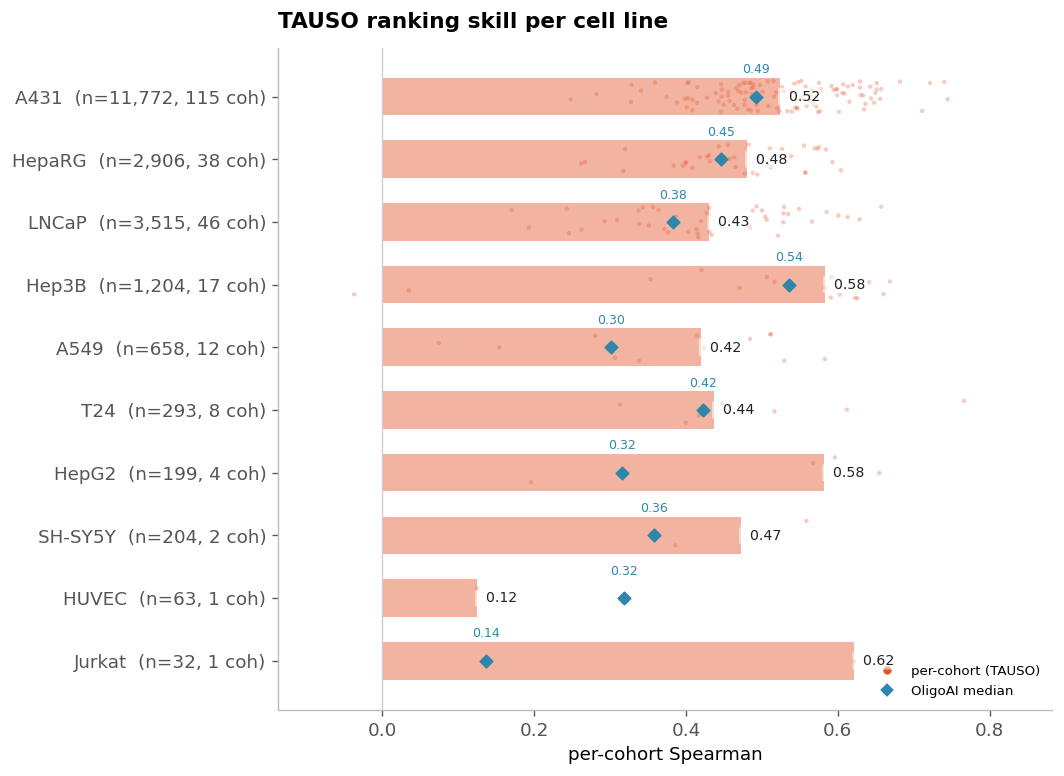

In [5]:
from matplotlib.lines import Line2D
nc = preds.groupby('Cell_line').custom_id.nunique().sort_values(ascending=False)
dist  = {c: v.per_cohort_spearman(preds[preds.Cell_line==c], 'TAUSO') for c in nc.index}
distA = {c: v.per_cohort_spearman(preds[preds.Cell_line==c], 'oligo_ai_score') for c in nc.index}
cls = [c for c in nc.index if len(dist[c])]
lbl = [f'{c}  (n={int((preds.Cell_line==c).sum()):,}, {len(dist[c])} coh)' for c in cls]
fig, ax = plt.subplots(figsize=(9, .52*len(cls)+1.4))
v.hbar_dist(ax, lbl, [np.median(dist[c]) for c in cls], [dist[c] for c in cls],
            colors=[v.ACCENT]*len(cls), title='TAUSO ranking skill per cell line', xlabel='per-cohort Spearman')
yy = np.arange(len(cls))[::-1]
for yi, c in zip(yy, cls):
    m = np.median(distA[c]) if len(distA[c]) else np.nan
    if np.isfinite(m):
        ax.scatter(m, yi, marker='D', s=28, color=v.BLUE, zorder=6)
        ax.text(m, yi+0.33, f'{m:.2f}', color=v.BLUE, fontsize=7.5, ha='center', va='bottom', zorder=7)
ax.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=v.ACCENT,markersize=6,label='per-cohort (TAUSO)'),
                   Line2D([0],[0],marker='D',color='w',markerfacecolor=v.BLUE,markersize=7,label='OligoAI median')],
          frameon=False, fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

In [6]:
# cell-line table with inhibition range + an A431-excluded aggregate (A431 is ~half the test rows)
tbl = ta[['n_samples','n_genes','n_cohorts_total','inhib_min','inhib_max','inhib_mean','base_hit70','spearman_median']].copy()
tbl = tbl.rename(columns={'spearman_median':'TAUSO'}); tbl['OligoAI'] = oa.reindex(tbl.index)
big = tbl[tbl.n_samples>=200]
agg = pd.Series({'n_samples':big.n_samples.sum(),'TAUSO':np.average(big.TAUSO,weights=big.n_cohorts_total),'OligoAI':np.average(big.OligoAI.fillna(0),weights=big.n_cohorts_total)}, name='—weighted (n≥200)')
no431 = big.drop(index='A431', errors='ignore')
agg2 = pd.Series({'n_samples':no431.n_samples.sum(),'TAUSO':np.average(no431.TAUSO,weights=no431.n_cohorts_total),'OligoAI':np.average(no431.OligoAI.fillna(0),weights=no431.n_cohorts_total)}, name='—weighted, A431 excluded')
print('Aggregates (custom_id-weighted over cell lines with n≥200):')
print(pd.DataFrame([agg, agg2])[['n_samples','TAUSO','OligoAI']].round(3).to_string())
tbl.round({'inhib_min':0,'inhib_max':0,'inhib_mean':1,'base_hit70':3,'TAUSO':3,'OligoAI':3})

Aggregates (custom_id-weighted over cell lines with n≥200):
                          n_samples  TAUSO  OligoAI
—weighted (n≥200)           20552.0  0.494    0.454
—weighted, A431 excluded     8780.0  0.468    0.420


,n_samples,n_genes,n_cohorts_total,inhib_min,inhib_max,inhib_mean,base_hit70,TAUSO,OligoAI
slice,,,,,,,,,
A431,11772,4,125,0.0,100.0,48.8,0.309,0.523,0.492
LNCaP,3515,1,47,0.0,99.0,31.8,0.109,0.431,0.383
HepaRG,2906,1,49,0.0,99.0,43.7,0.141,0.480,0.446
Hep3B,1204,1,17,0.0,96.0,50.3,0.288,0.583,0.536
A549,658,7,12,0.0,100.0,63.6,0.500,0.419,0.302
T24,293,6,8,0.0,98.0,63.5,0.519,0.437,0.423
SH-SY5Y,204,1,2,0.0,90.0,38.1,0.167,0.472,0.358
HepG2,199,3,7,0.0,98.0,68.3,0.673,0.567,0.300
HUVEC,63,1,1,0.0,46.0,15.2,0.000,0.124,0.318


## Top-of-list metrics — P@5, P@10, top-5% inhibition

Ranking metrics are computed **per `custom_id` cohort** (= one gene × cell line × assay — the
unit where oligos are directly comparable) and summarised as the **mean over cohorts**. These
metrics are discrete within a cohort (P@5 is a multiple of 0.2, P@10 a multiple of 0.1), so a
median sticks on a round value and is identical across models; the mean is the informative
summary.

- `P@5 / P@10` = fraction of the predicted top-5 / top-10 that are in the true top-5 / top-10.
- `top-5% inhib` = mean true inhibition of the predicted top 5 % of the cohort (k = max(1, round(0.05·n))).

The **overall** panel (all custom_id cohorts, no slicing) is the headline; the per-chemistry and
per-cell-line panels follow. All headline scorers are shown (`_viz.HEADLINE`).

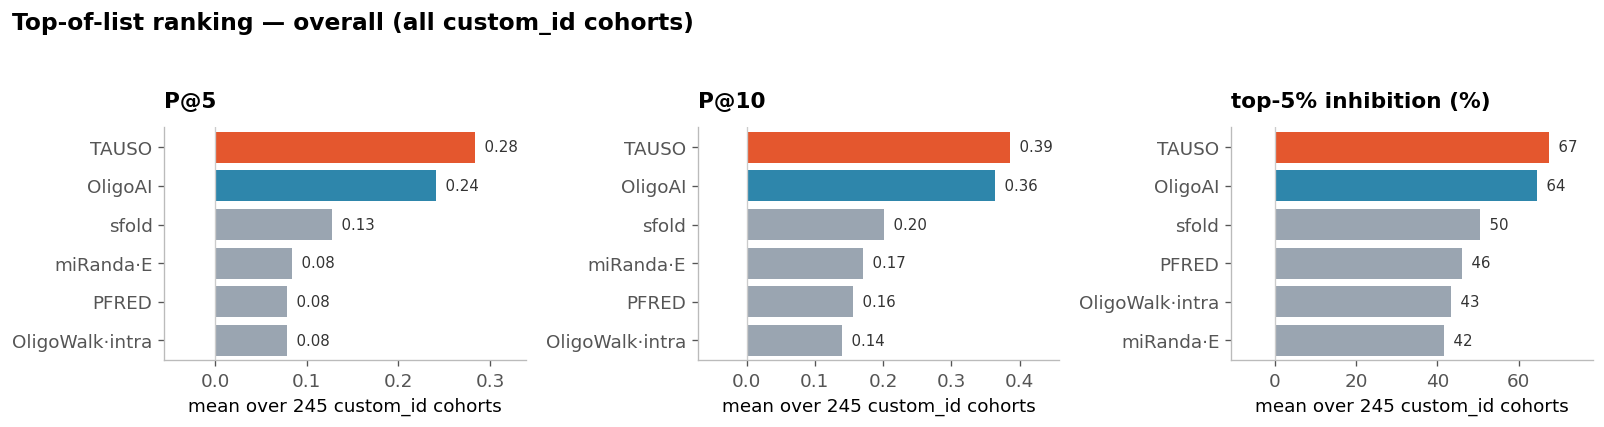

,p@5,p@10,top5pct_inhib,n_cohorts
TAUSO,0.284,0.386,67.461,245.0
OligoAI,0.241,0.364,64.483,245.0
OligoWalk·intra,0.079,0.139,43.413,245.0
sfold,0.128,0.201,50.428,245.0
PFRED,0.079,0.156,46.036,245.0
miRanda·E,0.084,0.171,41.529,245.0


In [7]:
# OVERALL (headline) — P@5 / P@10 / top-5% inhibition over ALL custom_id cohorts, no slicing.
# Self-contained: computed straight from the predictions table (mean over cohorts, same per-cohort
# logic as the slices), for every headline scorer.
HEAD = v.HEADLINE
overall = pd.DataFrame({s: v.topk_means(preds, s) for s in HEAD}).T  # rows = scorers
n_coh = int(overall['n_cohorts'].max())

METRICS = [('p@5', 'P@5', '{:.2f}'), ('p@10', 'P@10', '{:.2f}'),
           ('top5pct_inhib', 'top-5% inhibition (%)', '{:.0f}')]
fig, ax = plt.subplots(1, len(METRICS), figsize=(13.5, 3.6))
for a, (m, mlabel, fmt) in zip(ax, METRICS):
    o = v.order(overall.reset_index().rename(columns={'index': 'scorer'}), m, subset=HEAD)
    v.hbar(a, o, overall.loc[o, m].values, title=mlabel,
           xlabel=f'mean over {n_coh} custom_id cohorts', fmt=fmt)
fig.suptitle('Top-of-list ranking — overall (all custom_id cohorts)',
             x=0.012, ha='left', fontweight='bold', fontsize=14)
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()
overall[['p@5', 'p@10', 'top5pct_inhib', 'n_cohorts']].rename(index=v.DISPLAY).round(3)

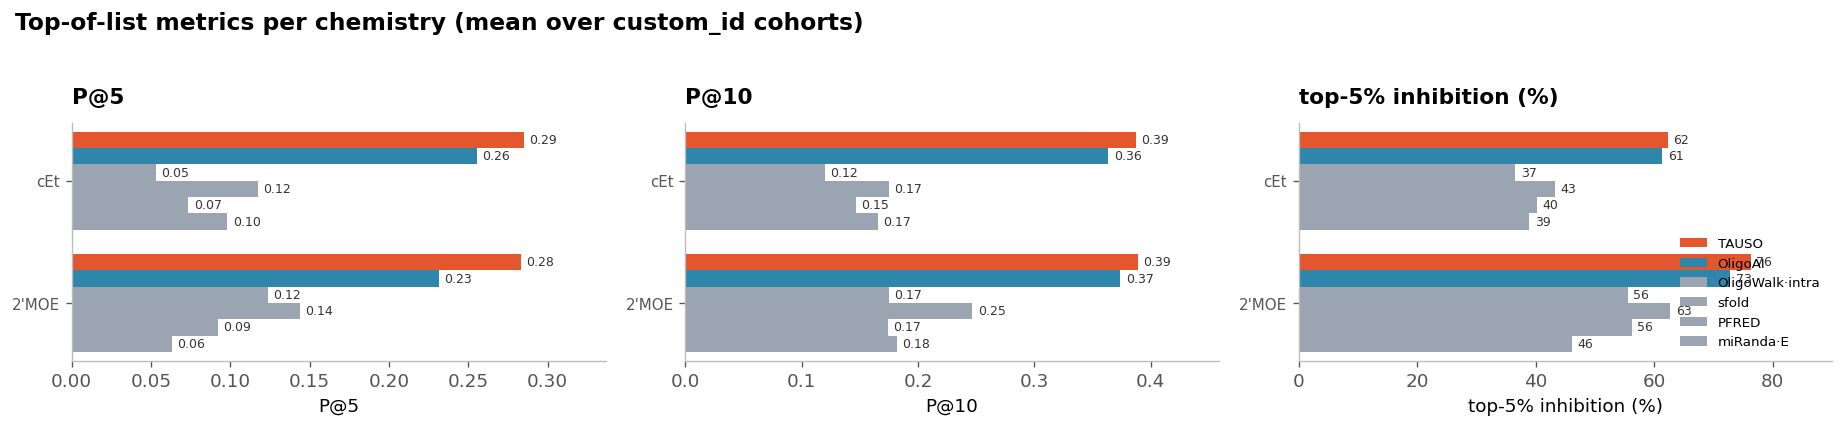

In [8]:
# Per-slice top-of-list metrics for all headline scorers (mean over the slice's custom_id cohorts).
# One panel per metric; slices on the y-axis, one grouped bar per scorer.
def breakdown_fig(name, slices, height=4.2):
    """Grid of metric panels (P@5 | P@10 | top-5%) for `slices` (ordered top->bottom)."""
    bd = breakdown[breakdown.breakdown == name]
    piv = {s: bd[bd.scorer == s].set_index('slice') for s in HEAD}
    fig, ax = plt.subplots(1, len(METRICS), figsize=(15.5, height), squeeze=False)
    for c, (m, mlabel, fmt) in enumerate(METRICS):
        series = {s: piv[s].reindex(slices)[f'{m}_mean'].values for s in HEAD if s in piv}
        v.grouped_hbar(ax[0][c], slices, series, title=mlabel, xlabel=mlabel, fmt=fmt)
        if c == len(METRICS) - 1:
            ax[0][c].legend(frameon=False, fontsize=8, loc='lower right')
    fig.suptitle(f'Top-of-list metrics per {name.replace("_"," ").lower()} (mean over custom_id cohorts)',
                 x=0.012, ha='left', fontweight='bold', fontsize=14)
    plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()


# chemistry: 2 slices, ordered by sample count
chem_order = breakdown[breakdown.breakdown=='chemistry'].drop_duplicates('slice') \
                .sort_values('n_samples', ascending=False)['slice'].tolist()
breakdown_fig('chemistry', chem_order, height=3.6)

cell lines shown (n_cohorts_total>=5): ['A431', 'LNCaP', 'HepaRG', 'Hep3B', 'A549', 'T24', 'HepG2']


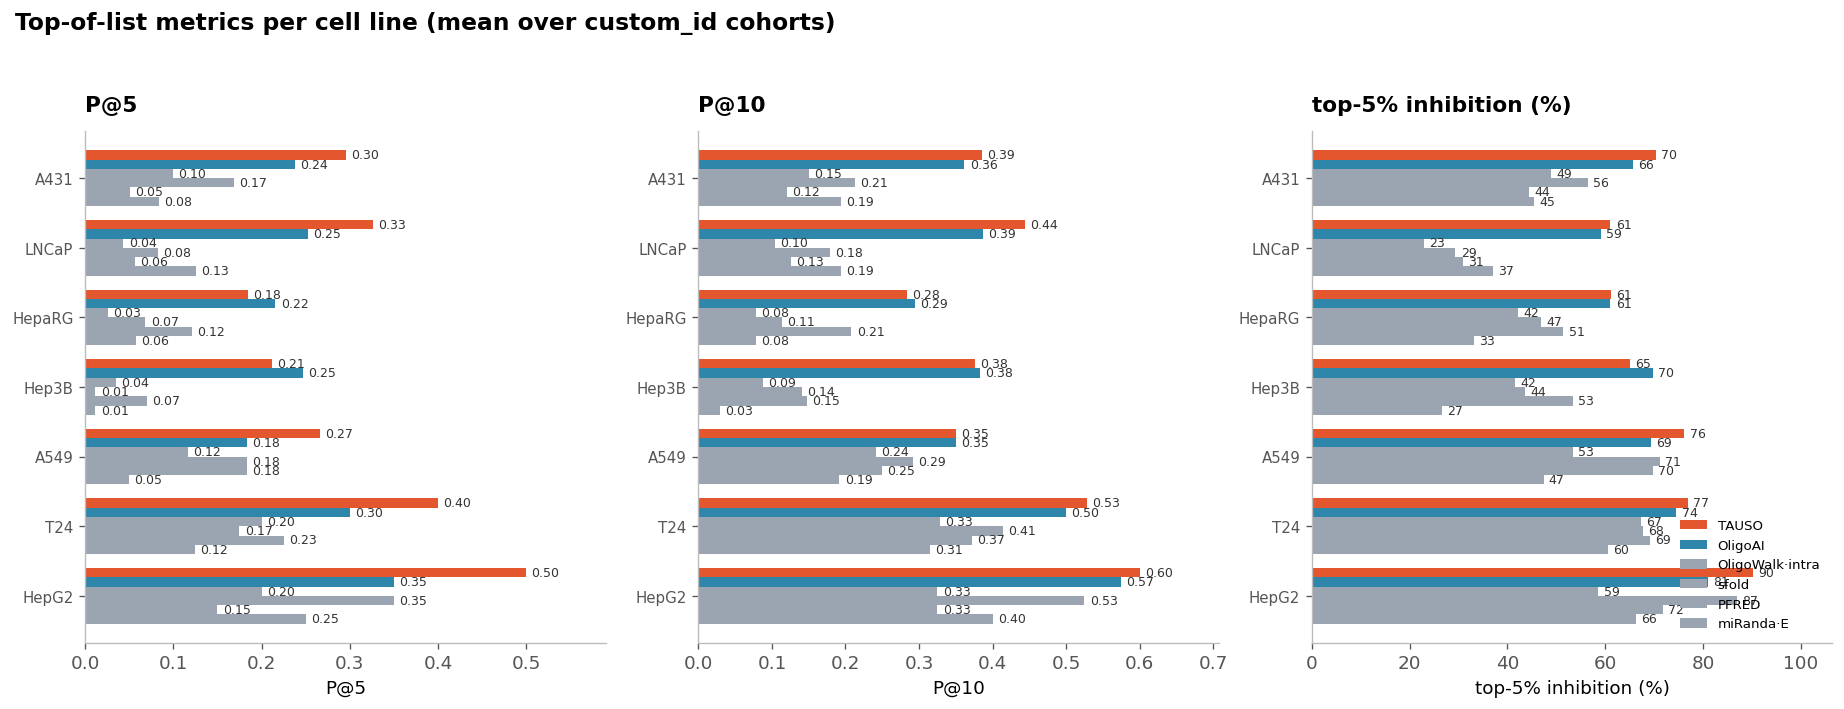

In [9]:
# per cell line: keep cell lines with >=5 custom_id cohorts (smaller ones make P@k means unstable),
# ordered by sample count
cl = breakdown[breakdown.breakdown=='Cell_line'].drop_duplicates('slice')
cell_order = cl[cl.n_cohorts_total>=5].sort_values('n_samples', ascending=False)['slice'].tolist()
print('cell lines shown (n_cohorts_total>=5):', cell_order)
breakdown_fig('Cell_line', cell_order, height=6.0)

In [10]:
# Compact numeric table: P@5 / P@10 / top-5% (mean over custom_id cohorts) per slice, headline scorers.
def metric_table(name, slices):
    bd = breakdown[breakdown.breakdown == name]
    rows = {}
    for sl in slices:
        rec = {}
        for s in HEAD:
            r = bd[(bd.scorer == s) & (bd.slice == sl)]
            if r.empty:
                continue
            r = r.iloc[0]
            for m, mlabel, _ in METRICS:
                rec[(mlabel, v.disp(s))] = r[f'{m}_mean']
        rows[sl] = rec
    out = pd.DataFrame(rows).T
    out.columns = pd.MultiIndex.from_tuples(out.columns)
    return out.round(2)

print('Chemistry:'); display(metric_table('chemistry', chem_order))
print('\nCell line:'); display(metric_table('Cell_line', cell_order))

Chemistry:


,P@5,P@10,top-5% inhibition (%),P@5,P@10,top-5% inhibition (%),P@5,P@10,top-5% inhibition (%),P@5,P@10,top-5% inhibition (%),P@5,P@10,top-5% inhibition (%),P@5,P@10,top-5% inhibition (%)
,TAUSO,TAUSO,TAUSO,OligoAI,OligoAI,OligoAI,OligoWalk·intra,OligoWalk·intra,OligoWalk·intra,sfold,sfold,sfold,PFRED,PFRED,PFRED,miRanda·E,miRanda·E,miRanda·E
cEt,0.29,0.39,62.33,0.26,0.36,61.34,0.05,0.12,36.55,0.12,0.17,43.30,0.07,0.15,40.16,0.10,0.17,38.93
2'MOE,0.28,0.39,76.30,0.23,0.37,72.83,0.12,0.18,55.51,0.14,0.25,62.71,0.09,0.17,56.16,0.06,0.18,46.04



Cell line:


,P@5,P@10,top-5% inhibition (%),P@5,P@10,top-5% inhibition (%),P@5,P@10,top-5% inhibition (%),P@5,P@10,top-5% inhibition (%),P@5,P@10,top-5% inhibition (%),P@5,P@10,top-5% inhibition (%)
,TAUSO,TAUSO,TAUSO,OligoAI,OligoAI,OligoAI,OligoWalk·intra,OligoWalk·intra,OligoWalk·intra,sfold,sfold,sfold,PFRED,PFRED,PFRED,miRanda·E,miRanda·E,miRanda·E
A431,0.30,0.39,70.30,0.24,0.36,65.58,0.10,0.15,48.89,0.17,0.21,56.44,0.05,0.12,44.41,0.08,0.19,45.42
LNCaP,0.33,0.44,61.04,0.25,0.39,59.15,0.04,0.10,22.95,0.08,0.18,29.37,0.06,0.13,30.88,0.13,0.19,37.04
HepaRG,0.18,0.28,61.16,0.22,0.29,61.05,0.03,0.08,42.15,0.07,0.11,46.90,0.12,0.21,51.41,0.06,0.08,33.11
Hep3B,0.21,0.38,65.01,0.25,0.38,69.79,0.04,0.09,41.57,0.01,0.14,43.65,0.07,0.15,53.31,0.01,0.03,26.63
A549,0.27,0.35,76.16,0.18,0.35,69.35,0.12,0.24,53.32,0.18,0.29,71.11,0.18,0.25,69.73,0.05,0.19,47.38
T24,0.40,0.53,76.81,0.30,0.50,74.50,0.20,0.33,67.25,0.18,0.41,67.77,0.22,0.37,69.17,0.12,0.31,60.50
HepG2,0.50,0.60,90.20,0.35,0.57,80.90,0.20,0.32,58.60,0.35,0.52,86.95,0.15,0.32,71.70,0.25,0.40,66.25
